# Reddit Reproduction: SGC / FastGCN / GCN

This notebook reproduces the Reddit part of **Simplifying Graph Convolutional Networks**.

## Models
1. **SGC**
   - Same structure as Peijie Li's SGC base model.
   - Uses paper-style Reddit preprocessing:
     - train-node subgraph
     - feature standardization
     - sparse \(S^KX\) precompute
     - L-BFGS optimizer
2. **FastGCN**
   - Same structural style as Yongnan Zhong / Ziwei Liu's notebook:
     - `FastGCNConv`
     - `FastGCN`
     - `precompute`
     - `_sample`
     - `train_model`
   - Uses importance sampling with probability proportional to squared column norm of normalized adjacency.
3. **GCN**
   - Reported as OOM / not scalable on Reddit, consistent with the paper.


## 1. Install Dependencies

In [ ]:
import sys
import subprocess
import importlib.util

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

if importlib.util.find_spec("torch_geometric") is None:
    pip_install("torch-geometric")

if importlib.util.find_spec("sklearn") is None:
    pip_install("scikit-learn")

if importlib.util.find_spec("tabulate") is None:
    pip_install("tabulate")


## 2. Imports and Setup

In [ ]:
import gc
import time
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from tabulate import tabulate

from torch_geometric.datasets import Reddit
from torch_geometric.nn.conv.gcn_conv import gcn_norm
from torch_geometric.utils import subgraph

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Torch:", torch.__version__)
print("CUDA:", torch.version.cuda)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

set_seed(42)


Device: cuda
Torch: 2.10.0+cu128
CUDA: 12.8


## 3. Load Reddit Dataset

In [ ]:
dataset = Reddit(root="/tmp/Reddit")
data = dataset[0]

print(dataset)
print(data)

stats = [
    ["# Nodes", f"{data.num_nodes:,}"],
    ["# Edges", f"{data.num_edges:,}"],
    ["# Features", f"{dataset.num_features:,}"],
    ["# Classes", f"{dataset.num_classes:,}"],
    ["Train / Val / Test", f"{int(data.train_mask.sum()):,} / {int(data.val_mask.sum()):,} / {int(data.test_mask.sum()):,}"],
]

print(tabulate(stats, tablefmt="github"))

data = data.to(device)


Extracting /tmp/Reddit/raw/reddit.zip
Processing...
Done!


Reddit()
Data(x=[232965, 602], edge_index=[2, 114615892], y=[232965], train_mask=[232965], val_mask=[232965], test_mask=[232965])
|--------------------|---------------------------|
| # Nodes            | 232,965                   |
| # Edges            | 114,615,892               |
| # Features         | 602                       |
| # Classes          | 41                        |
| Train / Val / Test | 153,431 / 23,831 / 55,703 |


## 4. Utility Functions

In [ ]:
def micro_f1(pred, y):
    return f1_score(
        y.detach().cpu().numpy(),
        pred.detach().cpu().numpy(),
        average="micro",
    )

def fmt_score(x):
    if isinstance(x, str):
        return x
    return f"{100 * x:.2f}"

def fmt_time(x):
    if isinstance(x, str):
        return x
    return f"{x:.2f}s"


## 5. Create Train-only Subgraph for SGC

In [ ]:
loss_histories = {
    "SGC": [],
    "FastGCN": []
}

In [ ]:
def make_train_subgraph(full_data):
    train_nodes = full_data.train_mask.nonzero(as_tuple=False).view(-1)

    edge_index_train, _ = subgraph(
        subset=train_nodes,
        edge_index=full_data.edge_index,
        relabel_nodes=True,
        num_nodes=full_data.num_nodes,
    )

    class SimpleData:
        pass

    train_data = SimpleData()
    train_data.x = full_data.x[train_nodes]
    train_data.y = full_data.y[train_nodes]
    train_data.edge_index = edge_index_train
    train_data.num_nodes = train_nodes.numel()

    return train_data, train_nodes

train_data, train_nodes = make_train_subgraph(data)

print("Train subgraph x:", train_data.x.shape)
print("Train subgraph edge_index:", train_data.edge_index.shape)
print("Train subgraph y:", train_data.y.shape)


Train subgraph x: torch.Size([153431, 602])
Train subgraph edge_index: torch.Size([2, 52284760])
Train subgraph y: torch.Size([153431])


## 6. Feature Standardization

In [ ]:
@torch.no_grad()
def standardize_reddit_features(train_data, full_data):
    scaler = StandardScaler()

    train_x_np = train_data.x.detach().cpu().numpy()
    scaler.fit(train_x_np)

    train_data.x = torch.from_numpy(
        scaler.transform(train_x_np)
    ).float().to(device)

    full_x_np = full_data.x.detach().cpu().numpy()
    full_data.x = torch.from_numpy(
        scaler.transform(full_x_np)
    ).float().to(device)

    return train_data, full_data

train_data, data = standardize_reddit_features(train_data, data)

print("After standardization:")
print("Train mean:", float(train_data.x.mean()))
print("Train std:", float(train_data.x.std()))


After standardization:
Train mean: -9.251209173721797e-12
Train std: 0.9999999403953552


## 7. SGC Model

In [ ]:
class SGC(nn.Module):
    # Same structure as Peijie Li's SGC:
    # propagate_features -> precompute -> forward -> cached features.
    # Reddit-safe implementation uses torch.sparse.mm.

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        K: int = 2,
        bias: bool = True,
        cached: bool = True,
        dropout: float = 0.0,
    ):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.K = K
        self.cached = cached
        self.dropout = dropout

        self.linear = nn.Linear(in_channels, out_channels, bias=bias)
        self._cached_x = None
        self.reset_parameters()

    def reset_parameters(self):
        self.linear.reset_parameters()
        self._cached_x = None

    def clear_cache(self):
        self._cached_x = None

    @torch.no_grad()
    def propagate_features(self, x, edge_index, edge_weight=None):
        num_nodes = x.size(0)

        edge_index_norm, edge_weight_norm = gcn_norm(
            edge_index=edge_index,
            edge_weight=edge_weight,
            num_nodes=num_nodes,
            add_self_loops=True,
            dtype=x.dtype,
        )

        adj = torch.sparse_coo_tensor(
            edge_index_norm,
            edge_weight_norm,
            size=(num_nodes, num_nodes),
            device=x.device,
            dtype=x.dtype,
        ).coalesce()

        out = x
        for _ in range(self.K):
            out = torch.sparse.mm(adj, out)

        return out

    def precompute(self, x, edge_index, edge_weight=None):
        self._cached_x = self.propagate_features(x, edge_index, edge_weight)
        return self._cached_x

    def forward(self, x, edge_index, edge_weight=None):
        if self.cached and self._cached_x is not None:
            x_prop = self._cached_x
        else:
            x_prop = self.propagate_features(x, edge_index, edge_weight)
            if self.cached:
                self._cached_x = x_prop

        x_prop = F.dropout(x_prop, p=self.dropout, training=self.training)
        logits = self.linear(x_prop)
        return logits


## 8. Train and Evaluate SGC

In [ ]:
@torch.no_grad()
def evaluate_sgc_full_graph(model, full_data):
    model.eval()
    model.clear_cache()

    t0 = time.perf_counter()
    logits = model(full_data.x, full_data.edge_index)
    eval_time = time.perf_counter() - t0

    pred = logits.argmax(dim=1)

    train_f1 = micro_f1(pred[full_data.train_mask], full_data.y[full_data.train_mask])
    val_f1 = micro_f1(pred[full_data.val_mask], full_data.y[full_data.val_mask])
    test_f1 = micro_f1(pred[full_data.test_mask], full_data.y[full_data.test_mask])

    return train_f1, val_f1, test_f1, eval_time


def train_sgc_lbfgs(
    model,
    train_data,
    full_data,
    lr=1.0,
    weight_decay=0.0,
    steps=20,
    model_name="SGC",
):
    clear_memory()

    loss_histories["SGC"] = []

    t0 = time.perf_counter()
    model.precompute(train_data.x, train_data.edge_index)
    precompute_time = time.perf_counter() - t0

    optimizer = torch.optim.LBFGS(
        model.parameters(),
        lr=lr,
        max_iter=20,
        history_size=10,
        line_search_fn="strong_wolfe",
    )

    t0 = time.perf_counter()

    for step in range(1, steps + 1):
        model.train()

        def closure():
            optimizer.zero_grad()
            logits = model(train_data.x, train_data.edge_index)
            loss = F.cross_entropy(logits, train_data.y)

            if weight_decay > 0:
                l2 = sum((p ** 2).sum() for p in model.parameters())
                loss = loss + weight_decay * l2

            loss.backward()
            return loss

        loss = optimizer.step(closure)

        with torch.no_grad():
            logits = model(train_data.x, train_data.edge_index)
            true_loss = F.cross_entropy(logits, train_data.y).item()
            loss_histories["SGC"].append(true_loss)

            pred = logits.argmax(dim=1)
            train_f1 = micro_f1(pred, train_data.y)

        print(
            f"[{model_name}] Step {step:02d} | "
            f"Loss {true_loss:.4f} | Train Micro-F1 {train_f1:.4f}"
        )

    train_time = time.perf_counter() - t0
    train_f1, val_f1, test_f1, eval_time = evaluate_sgc_full_graph(model, full_data)

    return {
        "Dataset": "Reddit",
        "Model": "SGC",
        "Test Micro-F1": test_f1,
        "Val Micro-F1": val_f1,
        "Train Micro-F1": train_f1,
        "Precompute Time": precompute_time,
        "Train Time": train_time,
        "Eval Time": eval_time,
        "Total Time": precompute_time + train_time,
        "Note": "K=2; standardized; L-BFGS; train subgraph; full-graph eval",
    }

## 9. Run SGC

In [ ]:
sgc = SGC(
    in_channels=dataset.num_features,
    out_channels=dataset.num_classes,
    K=2,
    cached=True,
    dropout=0.0,
).to(device)

sgc_result = train_sgc_lbfgs(
    sgc,
    train_data,
    data,
    lr=1.0,
    weight_decay=0.0,
    steps=2,
    model_name="SGC/Reddit",
)

sgc_result


[SGC/Reddit] Step 01 | Loss 0.3298 | Train Micro-F1 0.9362
[SGC/Reddit] Step 02 | Loss 0.2243 | Train Micro-F1 0.9489


{'Dataset': 'Reddit',
 'Model': 'SGC',
 'Test Micro-F1': 0.9463404125451053,
 'Val Micro-F1': 0.9447778104150056,
 'Train Micro-F1': 0.9476377003343522,
 'Precompute Time': 0.812235740999995,
 'Train Time': 4.919443021000006,
 'Eval Time': 0.5381501549999257,
 'Total Time': 5.731678762000001,
 'Note': 'K=2; standardized; L-BFGS; train subgraph; full-graph eval'}

## 10. FastGCN Model

In [ ]:
class FastGCNConv(nn.Module):
    # FastGCN layer with paper-style importance correction.

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.linear = nn.Linear(in_channels, out_channels, bias=False)
        nn.init.xavier_uniform_(self.linear.weight)

    def forward(self, x, edge_index, edge_weight, sample_idx=None, sample_probs=None):
        N = x.size(0)

        if sample_idx is None:
            adj = torch.sparse_coo_tensor(
                edge_index,
                edge_weight,
                size=(N, N),
                device=x.device,
                dtype=x.dtype,
            ).coalesce()

            agg = torch.sparse.mm(adj, x)
            return self.linear(agg)

        row, col = edge_index

        sample_mask = torch.zeros(N, dtype=torch.bool, device=x.device)
        sample_mask[sample_idx] = True

        keep = sample_mask[col]
        row_kept = row[keep]
        col_kept_global = col[keep]
        w_kept = edge_weight[keep]

        local_map = torch.full((N,), -1, dtype=torch.long, device=x.device)
        local_map[sample_idx] = torch.arange(sample_idx.numel(), device=x.device)
        col_local = local_map[col_kept_global]

        m = sample_idx.numel()
        correction = 1.0 / (m * sample_probs[col_kept_global].clamp(min=1e-12))
        w_corrected = w_kept * correction

        sampled_adj = torch.sparse_coo_tensor(
            torch.stack([row_kept, col_local], dim=0),
            w_corrected,
            size=(N, m),
            device=x.device,
            dtype=x.dtype,
        ).coalesce()

        agg = torch.sparse.mm(sampled_adj, x[sample_idx])
        return self.linear(agg)


class FastGCN(nn.Module):
    # Same high-level structure as the citation-network notebooks.

    def __init__(self, in_channels, hidden_channels, out_channels, sample_size=4000, dropout=0.5):
        super().__init__()

        self.conv1 = FastGCNConv(in_channels, hidden_channels)
        self.conv2 = FastGCNConv(hidden_channels, out_channels)

        self.sample_size = sample_size
        self.dropout = dropout

        self._edge_index_norm = None
        self._edge_weight_norm = None
        self._sample_probs = None

    @torch.no_grad()
    def precompute(self, x, edge_index):
        N = x.size(0)

        ei, ew = gcn_norm(
            edge_index=edge_index,
            edge_weight=None,
            num_nodes=N,
            add_self_loops=True,
            dtype=x.dtype,
        )

        self._edge_index_norm = ei
        self._edge_weight_norm = ew

        col_norm_sq = torch.zeros(N, device=x.device, dtype=x.dtype)
        col_norm_sq.index_add_(0, ei[1], ew ** 2)
        self._sample_probs = col_norm_sq / col_norm_sq.sum()

    def _sample(self, N):
        return torch.multinomial(
            self._sample_probs,
            num_samples=min(self.sample_size, N),
            replacement=False,
        )

    def forward(self, x, edge_index=None):
        ei = self._edge_index_norm
        ew = self._edge_weight_norm
        N = x.size(0)

        if self.training:
            idx1 = self._sample(N)
            idx2 = self._sample(N)
        else:
            idx1 = idx2 = None

        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv1(x, ei, ew, sample_idx=idx1, sample_probs=self._sample_probs))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, ei, ew, sample_idx=idx2, sample_probs=self._sample_probs)

        return x


## 11. Train and Evaluate FastGCN

In [ ]:
@torch.no_grad()
def evaluate_fastgcn(model, full_data):
    model.eval()
    logits = model(full_data.x, full_data.edge_index)
    pred = logits.argmax(dim=1)

    train_f1 = micro_f1(pred[full_data.train_mask], full_data.y[full_data.train_mask])
    val_f1 = micro_f1(pred[full_data.val_mask], full_data.y[full_data.val_mask])
    test_f1 = micro_f1(pred[full_data.test_mask], full_data.y[full_data.test_mask])

    return train_f1, val_f1, test_f1


def train_fastgcn(
    model,
    full_data,
    lr=0.01,
    weight_decay=0.0,
    epochs=200,
    print_every=20,
    model_name="FastGCN",
):
    loss_histories["FastGCN"] = []

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val = 0.0
    best_test = 0.0
    best_epoch = 0
    last_train = 0.0

    t0 = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        logits = model(full_data.x, full_data.edge_index)
        loss = F.cross_entropy(
            logits[full_data.train_mask],
            full_data.y[full_data.train_mask]
        )

        loss.backward()
        optimizer.step()

        loss_histories["FastGCN"].append(loss.item())

        train_f1, val_f1, test_f1 = evaluate_fastgcn(model, full_data)
        last_train = train_f1

        if val_f1 > best_val:
            best_val = val_f1
            best_test = test_f1
            best_epoch = epoch

        if epoch % print_every == 0:
            print(
                f"[{model_name}] Epoch {epoch:03d} | "
                f"Loss {loss.item():.4f} | "
                f"Train {train_f1:.4f} | Val {val_f1:.4f} | Test {test_f1:.4f}"
            )

    train_time = time.perf_counter() - t0

    return {
        "Dataset": "Reddit",
        "Model": "FastGCN",
        "Test Micro-F1": best_test,
        "Val Micro-F1": best_val,
        "Train Micro-F1": last_train,
        "Precompute Time": 0.0,
        "Train Time": train_time,
        "Eval Time": "-",
        "Total Time": train_time,
        "Note": f"importance sampling; sample_size={model.sample_size}; best_epoch={best_epoch}",
    }

## 12. Run FastGCN

In [ ]:
clear_memory()
set_seed(42)

fastgcn = FastGCN(
    in_channels=dataset.num_features,
    hidden_channels=128,
    out_channels=dataset.num_classes,
    sample_size=4000,   # Increase to 8000 or 12000 if GPU memory allows
    dropout=0.5,
).to(device)

t0 = time.perf_counter()
fastgcn.precompute(data.x, data.edge_index)
fastgcn_precompute_time = time.perf_counter() - t0

print(f"[FastGCN] Precompute time: {fastgcn_precompute_time:.2f}s")

fastgcn_result = train_fastgcn(
    fastgcn,
    data,
    lr=0.01,
    weight_decay=0.0,
    epochs=200,
    print_every=20,
    model_name="FastGCN/Reddit",
)

fastgcn_result["Precompute Time"] = fastgcn_precompute_time
fastgcn_result["Total Time"] = fastgcn_result["Train Time"] + fastgcn_precompute_time

fastgcn_result


[FastGCN] Precompute time: 0.27s
[FastGCN/Reddit] Epoch 020 | Loss 2.8539 | Train 0.8049 | Val 0.8217 | Test 0.8191
[FastGCN/Reddit] Epoch 040 | Loss 2.6695 | Train 0.8479 | Val 0.8598 | Test 0.8585
[FastGCN/Reddit] Epoch 060 | Loss 2.6292 | Train 0.8782 | Val 0.8915 | Test 0.8868
[FastGCN/Reddit] Epoch 080 | Loss 2.5670 | Train 0.8680 | Val 0.8813 | Test 0.8757
[FastGCN/Reddit] Epoch 100 | Loss 2.6504 | Train 0.8631 | Val 0.8752 | Test 0.8696
[FastGCN/Reddit] Epoch 120 | Loss 2.5145 | Train 0.8933 | Val 0.9045 | Test 0.9012
[FastGCN/Reddit] Epoch 140 | Loss 2.5630 | Train 0.8523 | Val 0.8634 | Test 0.8603
[FastGCN/Reddit] Epoch 160 | Loss 2.4772 | Train 0.8859 | Val 0.8952 | Test 0.8942
[FastGCN/Reddit] Epoch 180 | Loss 2.4899 | Train 0.8688 | Val 0.8779 | Test 0.8764
[FastGCN/Reddit] Epoch 200 | Loss 2.6486 | Train 0.8750 | Val 0.8872 | Test 0.8847


{'Dataset': 'Reddit',
 'Model': 'FastGCN',
 'Test Micro-F1': 0.9034522377609824,
 'Val Micro-F1': 0.9056690864839915,
 'Train Micro-F1': 0.8749535621875631,
 'Precompute Time': 0.27276534600002833,
 'Train Time': 1581.5890111549998,
 'Eval Time': '-',
 'Total Time': 1581.861776501,
 'Note': 'importance sampling; sample_size=4000; best_epoch=119'}

## 13. GCN OOM Baseline

In [ ]:
class GCN(nn.Module):
    # Full-batch GCN baseline.
    # Defined for completeness but not trained on Reddit because the paper reports it as OOM.

    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.lin1 = nn.Linear(in_channels, hidden_channels, bias=False)
        self.lin2 = nn.Linear(hidden_channels, out_channels, bias=False)
        self.dropout = dropout

    def forward(self, x, edge_index):
        edge_index_norm, edge_weight_norm = gcn_norm(
            edge_index=edge_index,
            edge_weight=None,
            num_nodes=x.size(0),
            add_self_loops=True,
            dtype=x.dtype,
        )

        adj = torch.sparse_coo_tensor(
            edge_index_norm,
            edge_weight_norm,
            size=(x.size(0), x.size(0)),
            device=x.device,
            dtype=x.dtype,
        ).coalesce()

        x = torch.sparse.mm(adj, x)
        x = self.lin1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = torch.sparse.mm(adj, x)
        x = self.lin2(x)
        return x

gcn_result = {
    "Dataset": "Reddit",
    "Model": "GCN",
    "Test Micro-F1": "OOM",
    "Val Micro-F1": "OOM",
    "Train Micro-F1": "OOM",
    "Precompute Time": "-",
    "Train Time": "OOM",
    "Eval Time": "-",
    "Total Time": "OOM",
    "Note": "Full-batch GCN not scalable on Reddit; reported OOM in paper",
}

gcn_result


{'Dataset': 'Reddit',
 'Model': 'GCN',
 'Test Micro-F1': 'OOM',
 'Val Micro-F1': 'OOM',
 'Train Micro-F1': 'OOM',
 'Precompute Time': '-',
 'Train Time': 'OOM',
 'Eval Time': '-',
 'Total Time': 'OOM',
 'Note': 'Full-batch GCN not scalable on Reddit; reported OOM in paper'}

## 14. Results Table

In [ ]:
results = [sgc_result, fastgcn_result, gcn_result]

rows = []
for r in results:
    rows.append([
        r["Dataset"],
        r["Model"],
        fmt_score(r["Test Micro-F1"]),
        fmt_score(r["Val Micro-F1"]),
        fmt_time(r["Precompute Time"]),
        fmt_time(r["Train Time"]),
        fmt_time(r["Total Time"]),
        r["Note"],
    ])

print("Reproduction results:")
print(tabulate(
    rows,
    headers=[
        "Dataset",
        "Model",
        "Test Micro-F1 (%)",
        "Val Micro-F1 (%)",
        "Precompute",
        "Train",
        "Total",
        "Note",
    ],
    tablefmt="github",
))

paper_rows = [
    ["Reddit", "SGC", "94.9", "1x"],
    ["Reddit", "FastGCN", "93.7", "100x"],
    ["Reddit", "GCN", "OOM", "OOM"],
]

print("\nPaper reference:")
print(tabulate(
    paper_rows,
    headers=[
        "Dataset",
        "Model",
        "Paper Test Micro-F1 (%)",
        "Paper Relative Time",
    ],
    tablefmt="github",
))


Reproduction results:
| Dataset   | Model   | Test Micro-F1 (%)   | Val Micro-F1 (%)   | Precompute   | Train    | Total    | Note                                                         |
|-----------|---------|---------------------|--------------------|--------------|----------|----------|--------------------------------------------------------------|
| Reddit    | SGC     | 94.63               | 94.48              | 0.81s        | 4.92s    | 5.73s    | K=2; standardized; L-BFGS; train subgraph; full-graph eval   |
| Reddit    | FastGCN | 90.35               | 90.57              | 0.27s        | 1581.59s | 1581.86s | importance sampling; sample_size=4000; best_epoch=119        |
| Reddit    | GCN     | OOM                 | OOM                | -            | OOM      | OOM      | Full-batch GCN not scalable on Reddit; reported OOM in paper |

Paper reference:
| Dataset   | Model   | Paper Test Micro-F1 (%)   | Paper Relative Time   |
|-----------|---------|--------------------------

## 15. Figure 3 Style Plot

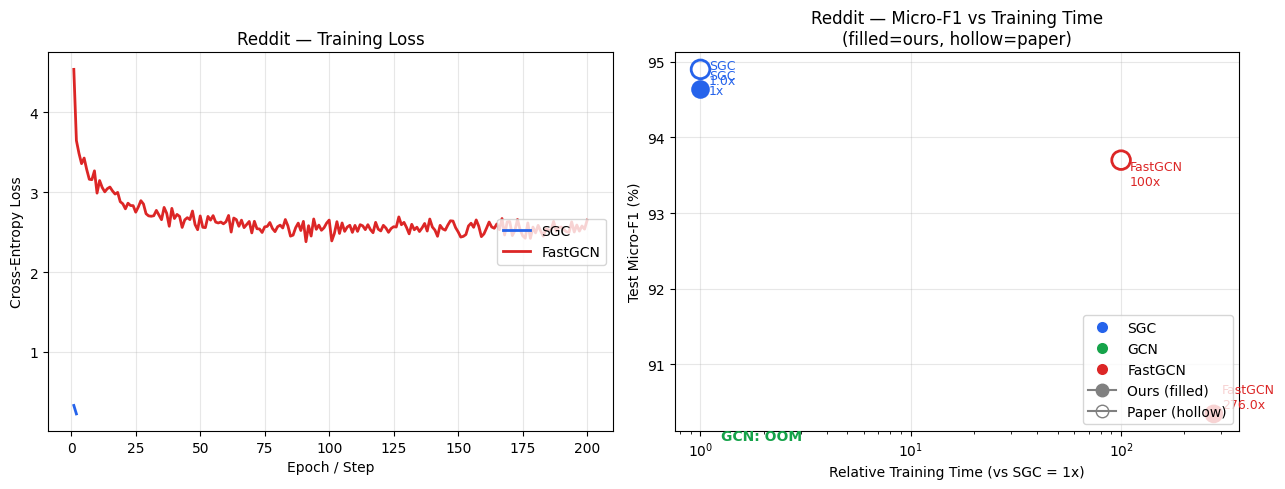

In [ ]:
from matplotlib.lines import Line2D

plot_results = [r for r in results if not isinstance(r["Total Time"], str)]
sgc_time = sgc_result["Total Time"]

colors = {
    "SGC": "#2563EB",
    "GCN": "#16A34A",
    "FastGCN": "#DC2626",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Real Training Loss
ax = axes[0]

if len(loss_histories["SGC"]) > 0:
    ax.plot(
        range(1, len(loss_histories["SGC"]) + 1),
        loss_histories["SGC"],
        color=colors["SGC"],
        linewidth=2,
        label="SGC",
    )

if len(loss_histories["FastGCN"]) > 0:
    ax.plot(
        range(1, len(loss_histories["FastGCN"]) + 1),
        loss_histories["FastGCN"],
        color=colors["FastGCN"],
        linewidth=2,
        label="FastGCN",
    )

ax.set_title("Reddit — Training Loss")
ax.set_xlabel("Epoch / Step")
ax.set_ylabel("Cross-Entropy Loss")
ax.grid(alpha=0.3)
ax.legend(loc="center right", frameon=True)

# Right: Figure 3 Style Plot
ax = axes[1]

for r in plot_results:
    rel_time = r["Total Time"] / sgc_time
    f1 = 100 * r["Test Micro-F1"]

    ax.scatter(
        rel_time,
        f1,
        s=180,
        color=colors[r["Model"]],
        edgecolors="none",
        zorder=3,
    )

    ax.annotate(
        f'{r["Model"]}\n{rel_time:.1f}x',
        (rel_time, f1),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=9,
        color=colors[r["Model"]],
    )

# Paper hollow points
paper_points = [
    ("SGC", 1.0, 94.9),
    ("FastGCN", 100.0, 93.7),
]

for model, rel_time, f1 in paper_points:
    ax.scatter(
        rel_time,
        f1,
        s=180,
        facecolors="none",
        edgecolors=colors[model],
        linewidths=2,
        zorder=3,
    )

    ax.annotate(
        f"{model}\n{rel_time:.0f}x",
        (rel_time, f1),
        textcoords="offset points",
        xytext=(6, -18),
        fontsize=9,
        color=colors[model],
    )

ax.text(
    1.25,
    90,
    "GCN: OOM",
    color=colors["GCN"],
    fontsize=10,
    fontweight="bold",
)

ax.set_xscale("log")
ax.set_xlabel("Relative Training Time (vs SGC = 1x)")
ax.set_ylabel("Test Micro-F1 (%)")
ax.set_title("Reddit — Micro-F1 vs Training Time\n(filled=ours, hollow=paper)")
ax.grid(alpha=0.3)

legend_handles = [
    Line2D([0], [0], marker="o", color="w", label="SGC",
           markerfacecolor=colors["SGC"], markersize=9),
    Line2D([0], [0], marker="o", color="w", label="GCN",
           markerfacecolor=colors["GCN"], markersize=9),
    Line2D([0], [0], marker="o", color="w", label="FastGCN",
           markerfacecolor=colors["FastGCN"], markersize=9),
    Line2D([0], [0], marker="o", color="gray", label="Ours (filled)",
           markerfacecolor="gray", markersize=9),
    Line2D([0], [0], marker="o", color="gray", label="Paper (hollow)",
           markerfacecolor="none", markersize=9),
]

ax.legend(handles=legend_handles, loc="lower right", frameon=True)

plt.tight_layout()
plt.savefig("reddit_real_training_loss_and_figure3.png", dpi=200, bbox_inches="tight")
plt.show()